# Tutorial: BVA

A quick demonstration of computing and visualizing burst variance analysis from [Torella et. al. 2011](https://doi.org/10.1016/j.bpj.2011.01.066).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf

Load the data

In [2]:
raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

## Make Burst Search

The BVA column is created by `smf.fretfactory.make_burst_search`, the default chuck size is set by the `nbva` 

In [3]:
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, tail_min=5e-4)
nbva = 10
dbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')), nbva=nbva)
gate = smf.make_geq_gate(dbs['NphDex_raw'], 30) * smf.make_geq_gate(dbs['NphAA_raw'], 30)

It is always good to check the selection is reasonable in ES plots.

(-0.1, 1.1)

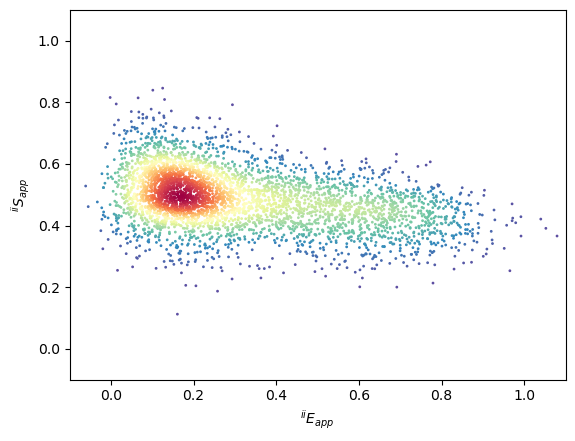

In [4]:
smf.plot.scatter(data, dbs['E_bg'], dbs['S_bg'], gate=gate, s=1.0, point_func=smf.plot.density_kde, cmap='Spectral_r')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

Now we can plot the BVA as the `BVA10` column (if nbva were for instance 5, then the column would be `BVA5`)
We compute the expected as static variance as sqrt{x(1-x)/n}$,
and we can plot the mean of an interval in `E_raw` with the `smf.plotscatter_meaninterval()` function.

Note the use of fully uncorrected proximity ratio, this is because the computation of expected variance is valid only between $[0,1]$

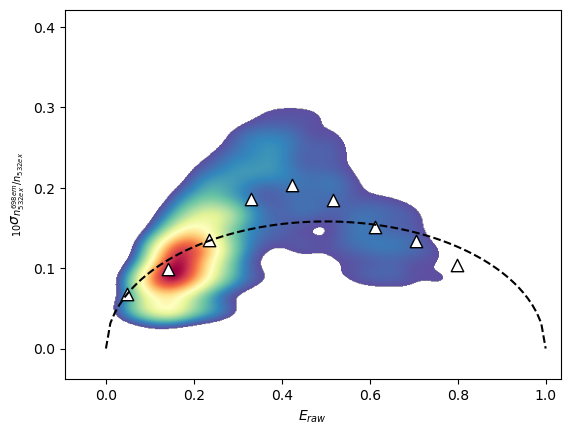

In [5]:
fig, ax = plt.subplots()
smf.plot.kdeplot(data, dbs['E_raw'], dbs['BVA10'], gate=gate, thresh=0.1, cmap='Spectral_r', ax=ax)
smf.plot.scatter_meaninterval(data, dbs['E_raw'], dbs['BVA10'], gate=gate, ax=ax, marker='^', c='w', ec='k', s=80)
x = np.linspace(0, 1, 100)
y_bva = np.sqrt(x*(1-x)/nbva)
ax.plot(x, y_bva, ls='--', c='k')

## Get Citations

As is best practice, let's get the citations:

In [6]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
4. Torella, J. P., Holden, S. J., Santoso, Y., Hohlbein, J. & Kapanidis, A. N.
    Identifying molecular dynamics in single-molecule fret experiments with
    burst variance analysis. Biophysical J. 100, 1568–1577 (2011).
